In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("../data/smard.csv", delimiter=";")

In [16]:
df

,timestamp,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load,Forecast Wind + Solar
0,2022-01-01 00:00,"5975,5","25570,25","2,0","43915,5","12367,75","31530,75"
1,2022-01-01 01:00,"5775,25","24318,25","2,0","41535,75","11440,25","30462,5"
2,2022-01-01 02:00,"5548,0","23169,5","2,0","40480,75","11761,25","29055,25"
3,2022-01-01 03:00,"5382,75","22092,5","2,0","39564,0","12086,75","27607,5"
4,2022-01-01 04:00,"5586,5","20607,0","2,0","39338,25","13142,75","26255,5"
...,...,...,...,...,...,...,...
41054,2026-09-07 19:00,"3761,03","12037,9","983,21","58419,29","41637,15","18674,68"
41055,2026-09-07 20:00,"3324,54","14581,27","0,48","56913,86","39007,57","18970,14"
41056,2026-09-07 21:00,"3655,88","14577,01","0,0","53900,51","35667,62","18998,88"
41057,2026-09-07 22:00,"3314,05","14284,31","0,0","50578,44","32980,07","18287,14"


In [17]:
df.rename(
    columns={
        "Wind Offshore": "wind_off",
        "Wind Onshore": "wind_on",
        "Forecast Wind + Solar": "fc"
    },
    inplace=True
)
df.columns

Index(['timestamp', 'wind_off', 'wind_on', 'Solar', 'Grid Load',
       'Residual Load', 'fc'],
      dtype='str')

In [18]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%d %H:%M")
df.dtypes

timestamp        datetime64[us]
wind_off                    str
wind_on                     str
Solar                       str
Grid Load                   str
Residual Load               str
fc                          str
dtype: object

In [19]:
numeric_cols = ["wind_off", "wind_on", "Solar", "Grid Load", "Residual Load", "fc"]
for col in numeric_cols:
    df[col] = df[col].str.replace(",", ".")
    df[col] = df[col].astype(float)

df.dtypes

timestamp        datetime64[us]
wind_off                float64
wind_on                 float64
Solar                   float64
Grid Load               float64
Residual Load           float64
fc                      float64
dtype: object

[]

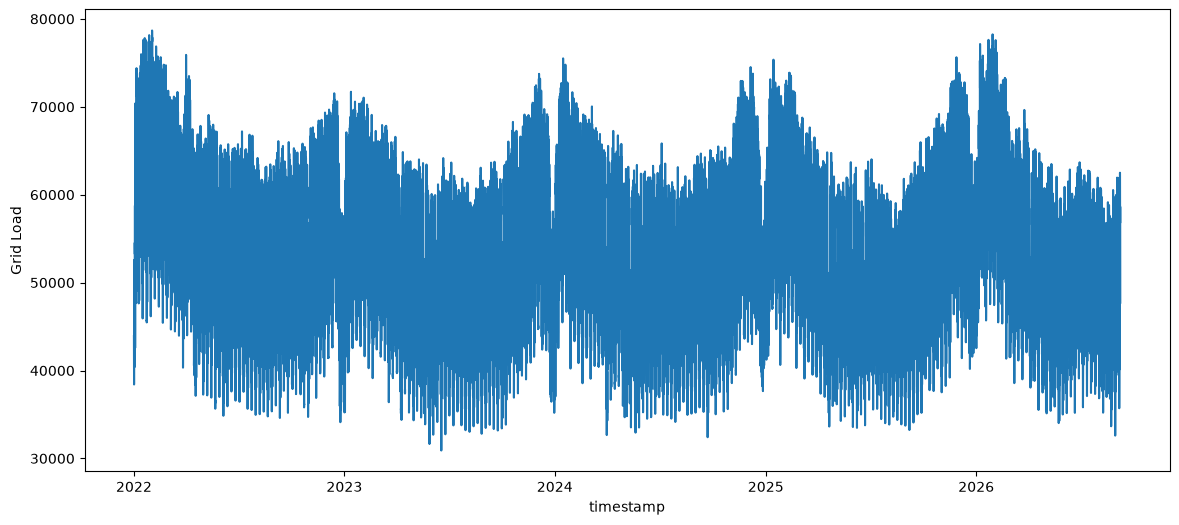

In [22]:
fig = plt.subplots(figsize=(14,6))
sns.lineplot(
    x="timestamp",
    y="Grid Load",
    data=df
)
plt.plot()